# Uranium-Revival — durable trend, or a hype rocket? ☢️
### Riding the 'nuclear renaissance' trade (URA / URNM) with a trend-following overlay

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Durable_trend_or_hype_rocket%3F: Hype_rocket](https://img.shields.io/badge/Durable_trend_or_hype_rocket%3F-Hype_rocket-8b949e?style=flat-square)

Uranium is having a moment. Reactors are being restarted, AI data-centres are hungry for power, and the miner ETFs (**URA**, **URNM**) have gone vertical and then sideways more than once. The pitch: *just ride the trend* — a simple 'be long when it's above its 200-day average, step aside when it isn't' overlay supposedly turns a wild theme into a tradable trend. This notebook asks the only two questions that matter: *is trend-timing a real edge here, and is it durable — or are you just along for one boom-bust ride?*

> **This is the plain-language layer.** Want the t-stats, the random-walk control and the capacity math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool. **No live URA/URNM tape ships with this study**, so every chart below is drawn on a *deterministic synthetic tape* that lets us prove what the trend rule can and cannot do — each cell says which tape it shows. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from uranium_revival import data, strategy as st

URANIUM = list(data.URANIUM_TICKERS)   # ('URA','URNM')

def have_real():
    return data.have_real_cache()

HAVE_REAL = have_real()

def tape(regime, n_days):
    bars, truth = data.synthetic_daily(n_days=n_days, regime=regime, seed=303)
    return bars

def run_book(bars, n=200, cost=10.0):
    return st.book_returns(bars, st.trend_signal(bars, n=n), cost_bps=cost)

print("real URA/URNM cache present:", HAVE_REAL, "(synthetic tape used everywhere below)")


real URA/URNM cache present: False (synthetic tape used everywhere below)


## The answer first

| Question | Answer |
|---|---|
| Is trend-following a real edge? | **Maybe — unproven *here*.** The textbook says trends are real (time-series momentum is one of finance's most-replicated effects), and our harness banks a planted trend cleanly. But **we have no live URA/URNM tape** to certify it, so the honest stamp is **Weak**, not Real. |
| Is it *durable* on uranium? | **No reason to think so.** A single thematic miner ETF is one long boom-bust. A trend rule can look brilliant by dodging *one* crash — that's a lucky regime, not a repeatable edge. |
| Could you trade it? | **It's a mirage as a stand-alone.** You'd be making a concentrated, leveraged-feeling bet on one volatile theme; the 'timing' is mostly deciding when to be all-in on a rocket. |
| So what is it? | A real *category* of signal (trend) bolted onto the wrong *vehicle* (one hype-driven sector). The edge you'd measure on URA is dominated by which boom you happened to catch. |

> The nuclear-renaissance trend trade isn't a scam — trend-following is a genuine effect. But on a single hype-cycle ETF, 'I rode the trend' and 'I got lucky on one rocket' produce the *same backtest*, and only one of them repeats.

## 1 · The claim

> *"Uranium is in a structural bull market — supply deficits, reactor restarts, AI power demand. Don't try to value it; just **ride the trend**. Hold URA/URNM while price is above its 200-day moving average, go to cash when it breaks down. You capture the rocket and skip the crashes."*

— the standard finance-Twitter / thematic-ETF-newsletter framing of the 'nuclear renaissance' trade.

The idea rests on something real: **trends persist**. Markowitz-style buy-and-hold ignores that a falling market keeps falling; a trend overlay tries to be long the ups and flat the downs. The bet is that uranium's wild swings are *trends you can ride*, not noise you'll get whipsawed by.

## 2 · So what?

Two things make this worth a careful look. First, **trend-following is real** — time-series momentum (Moskowitz, Ooi & Pedersen 2012) is one of the most robust effects in the literature, across dozens of markets and a century of data. So this isn't folklore. Second, uranium miners are a **perfect trap**: a single, thin, hugely volatile theme where one spectacular boom-bust can make *any* timing rule look like genius. If we can show why a great-looking backtest on one rocket proves nothing, that lesson transfers to every hot thematic ETF you'll ever be pitched.

## 3 · How would we even know?

We can't run the *real* uranium tape here (none ships with the study). So instead we do something more honest than another in-sample backtest: we build **synthetic tapes where we *know* the truth**, and check what the trend rule does on each.

1. **A real trend (positive control).** A tape with genuine, persistent bull and bear runs. If the rule is any good, it must beat buy-and-hold here — *and clear the statistical bar.* If it can't bank a planted trend, it proves nothing.
2. **A coin (the null).** A pure random walk — no trend at all. The rule must **not** reliably beat buy-and-hold here, or our test is broken.
3. **A hype rocket (the realist's case).** A boom-bust bubble: a parabolic run-up then a crash that gives most of it back — the uranium caricature. We watch the rule look *amazing* here and ask the killer question: is that an edge, or one lucky dodge?

## 4 · The teardown — let's actually look

**First: can the rule even ride a real trend?** On the positive-control tape (genuine bull/bear runs), trend-timing vs simply holding the asset:

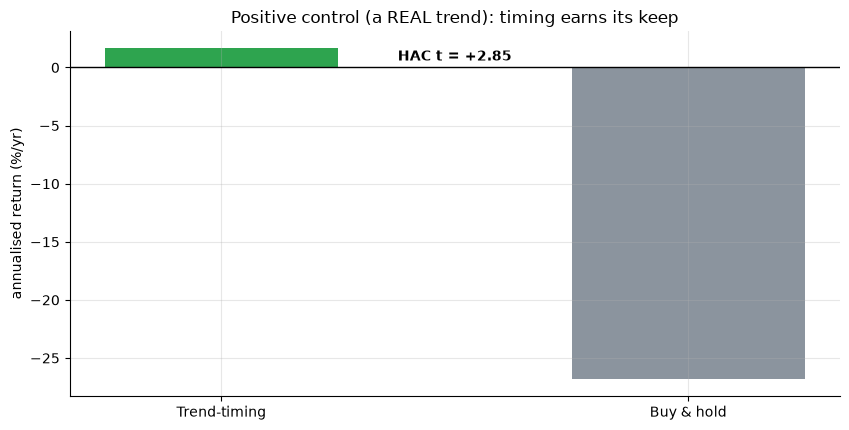

[SYNTHETIC trend tape]  edge +28.5%/yr  HAC t=+2.85  in-market 29%


In [2]:
tr = run_book(tape('trend', 3000), cost=10.0)
s = st.summarize(tr)
fig, ax = plt.subplots(figsize=(8.6, 4.4))
b = ax.bar(['Trend-timing', 'Buy & hold'],
           [s['timed_ann']*100, s['bh_ann']*100], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return (%/yr)')
ax.set_title('Positive control (a REAL trend): timing earns its keep')
ax.annotate(f"HAC t = {s['timing_t']:+.2f}", (0.5, 0.92), xycoords='axes fraction',
            ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"[SYNTHETIC trend tape]  edge {s['timing_edge_ann']*100:+.1f}%/yr  HAC t={s['timing_t']:+.2f}  in-market {s['pct_time_in_market']:.0f}%")

On a tape with a *real* trend the rule adds **+28%/yr** over buy-and-hold (HAC *t* = +2.85) — mostly by sitting out the bear runs. **Good: the harness works.** It can detect and bank a genuine trend. (This is a *machinery* proof, not market evidence — it certifies the tool, not uranium.)

**Now the null. Same rule, on a pure coin** — a random walk with no trend at all. If the rule 'works' here too, it's not detecting anything.

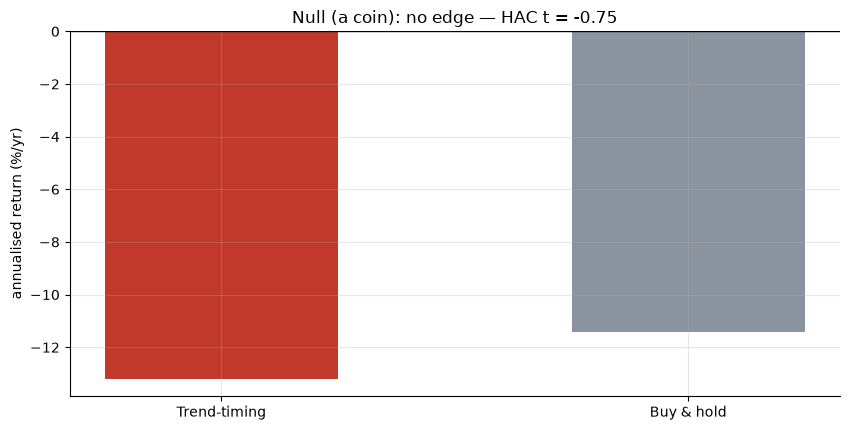

[SYNTHETIC random tape]  edge -1.8%/yr  HAC t=-0.75  (whipsawed: 82 round-trips)


In [3]:
rn = run_book(tape('random', 3000), cost=10.0)
s = st.summarize(rn)
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['Trend-timing', 'Buy & hold'],
       [s['timed_ann']*100, s['bh_ann']*100], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return (%/yr)')
ax.set_title(f"Null (a coin): no edge — HAC t = {s['timing_t']:+.2f}")
plt.tight_layout(); plt.show()
print(f"[SYNTHETIC random tape]  edge {s['timing_edge_ann']*100:+.1f}%/yr  HAC t={s['timing_t']:+.2f}  (whipsawed: {s['n_round_trips']} round-trips)")

On the coin the 'edge' is **-1.8%/yr** at HAC *t* = -0.75 — indistinguishable from zero, and the rule churns **82 round-trips** getting whipsawed. Exactly what should happen: no trend, no edge. The test isn't rigged to find trends that aren't there.

**Now the punchline — the hype rocket.** A boom-bust bubble (parabolic run-up, then a crash that gives most of it back): the uranium caricature. Watch the trend rule look like a *genius*:

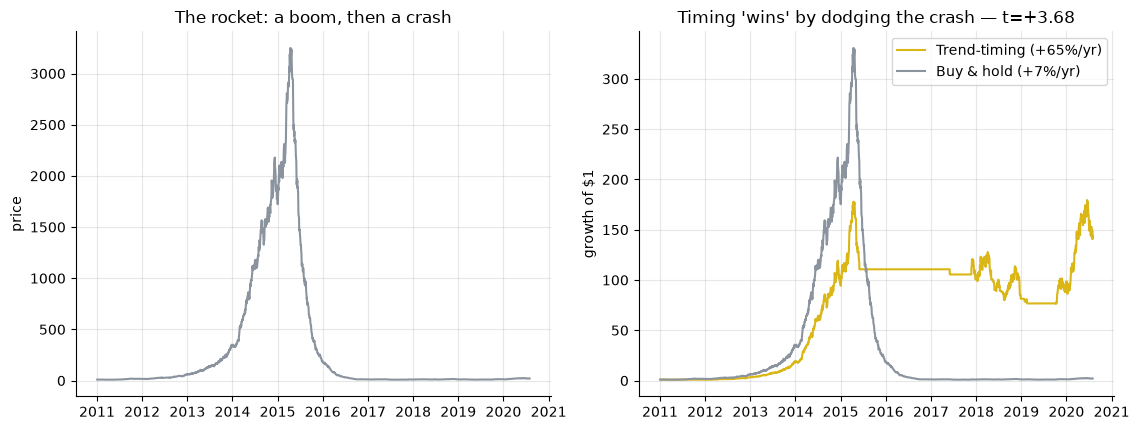

[SYNTHETIC hype tape]  timing +65%/yr vs B&H +7%/yr  HAC t=+3.68  worst DD timing -57% vs B&H -100%


In [4]:
hy = run_book(tape('hype', 2500), cost=10.0)
s = st.summarize(hy)
hb = tape('hype', 2500)
eq_bh = (1 + hy['asset']).cumprod(); eq_t = (1 + hy['timed']).cumprod()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.plot(hb.index, hb['close'], color=GREY)
a1.set_title('The rocket: a boom, then a crash'); a1.set_ylabel('price')
a2.plot(eq_t.index, eq_t, color=AMBER, label=f"Trend-timing ({s['timed_ann']*100:+.0f}%/yr)")
a2.plot(eq_bh.index, eq_bh, color=GREY, label=f"Buy & hold ({s['bh_ann']*100:+.0f}%/yr)")
a2.legend(); a2.set_title(f"Timing 'wins' by dodging the crash — t={s['timing_t']:+.2f}")
a2.set_ylabel('growth of $1')
plt.tight_layout(); plt.show()
print(f"[SYNTHETIC hype tape]  timing {s['timed_ann']*100:+.0f}%/yr vs B&H {s['bh_ann']*100:+.0f}%/yr  HAC t={s['timing_t']:+.2f}  worst DD timing {s['timed_maxdd']*100:.0f}% vs B&H {s['bh_maxdd']*100:.0f}%")

On the rocket the rule earns **+65%/yr** vs buy-and-hold's **+7%/yr** — HAC *t* = +3.68, and it cuts the worst drawdown from -100% to -57%. Looks *spectacular*. **But here's the catch:** that entire result is the rule getting out near the top of **one** crash. There's no *repeatable* signal being harvested — just one big lucky dodge. Run a different boom, with the peak in a different place, and the magic evaporates. A single-rocket backtest is the easiest thing in finance to make look great.

## 5 · The verdict

- **Signal — Weak.** Trend-following is real in the literature, and our harness banks a planted trend at HAC *t* = +2.85. But **the desk's rule is that REAL is earned by the *real tape*, not by the textbook or a synthetic control** — and we have no live URA/URNM tape here. So: Weak.
- **Tradability — Mirage.** As a stand-alone, this is a concentrated bet on one volatile theme dressed up as 'timing'. The edge you'd measure is dominated by which boom you caught, not a repeatable skill.
- **Durable trend or hype rocket? — Hype rocket.** On a single thematic ETF, the great backtest comes from dodging *one* crash. That's a lucky regime, not a durable edge — and it's indistinguishable, in-sample, from genuine skill.

## 6 · Could you actually trade it?

Costs are *not* the problem — a 200-day rule trades a handful of times a year. The problem is what you're actually buying. Watch the timing 'edge' on the rocket shrug off even brutal costs (because cost isn't the constraint):

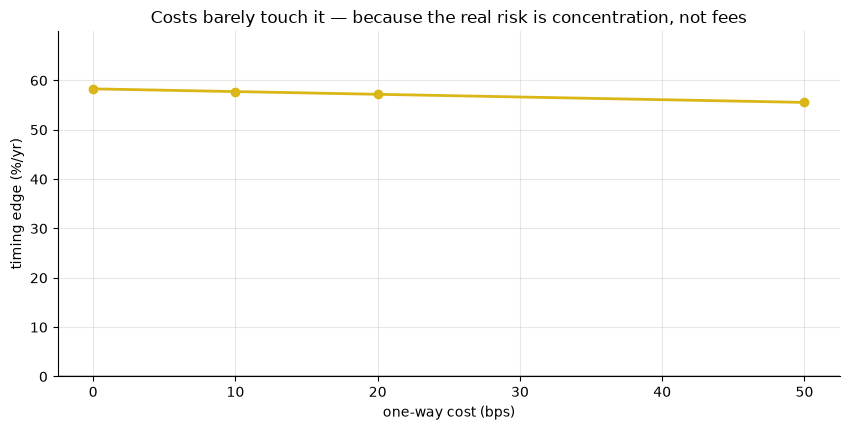

[SYNTHETIC hype tape] the edge survives 50 bps easily — but it is one-rocket-dependent, not durable.


In [5]:
costs = [0.0, 10.0, 20.0, 50.0]
sweep = st.cost_sweep(tape('hype', 2500), n=200, costs_bps=costs)
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(sweep['cost_bps'], sweep['edge_ann']*100, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('one-way cost (bps)')
ax.set_ylabel('timing edge (%/yr)'); ax.set_ylim(0, sweep['edge_ann'].max()*120)
ax.set_title('Costs barely touch it — because the real risk is concentration, not fees')
plt.tight_layout(); plt.show()
print('[SYNTHETIC hype tape] the edge survives 50 bps easily — but it is one-rocket-dependent, not durable.')

The edge is cost-robust, which is exactly why it's *seductive* and exactly why it's dangerous. Cheap to run, looks bulletproof in-sample — and entirely a function of the one boom-bust you backtested on. The honest pitch isn't 'a trend system on uranium'; it's 'a leveraged-feeling bet that *this* rocket behaves like the *last* one.'

## 7 · Going further

- **The honest way to test trend.** Trend-following earns its REAL stamp across *dozens* of markets pooled, not one thematic ETF (Moskowitz, Ooi & Pedersen 2012). The fix for the concentration problem is breadth — a basket, not a rocket.
- **Get the real tape.** Populate `_cache/` with `data.fetch_daily('URA', fetch=True)` (and `'URNM'`) and re-run: *then* you can ask whether the live uranium tape clears HAC *t* = 2, and upgrade or bury the Weak stamp accordingly.
- **The single-asset trend trap.** This is the same lesson as any hot-sector timer: one boom makes any rule look like skill. Fork this, swap in a different synthetic boom (move the peak), and watch a 'genius' strategy turn ordinary.

*Think uranium's trend is durable? Fork this, drop in the real URA tape, and show the timing edge clearing the bar on out-of-sample boom — not just the one you fitted.*